# Scenario 03 — Payload Size Sweep

Classical (X25519) vs hybrid PQ (X25519MLKEM768) across response sizes: 100B, 10K, 100K, 1M.

Uses resumed handshakes (shareConnections) so the handshake amortizes — the signal is bulk/record-layer transfer, not key exchange.

**Hypothesis**: once the handshake is amortized, the PQ-overhead curve should be ~flat across payload sizes — the record layer uses AES-256-GCM regardless of the KEM used.

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys

sys.path.insert(0, '.')
from parse_gatling import collect_results, summarize

In [4]:
RESULTS = "../results/2026-10-03-scenario-03-rate200"
df = collect_results(RESULTS)

# Split arm into (config, payload) e.g. pq-100K -> pq, 100K
df[["config", "payload"]] = df["arm"].str.split("-", n=1, expand=True)

# Order payloads by actual size, not lex
PAYLOAD_ORDER = ["100B", "10K", "100K", "1M"]
PAYLOAD_BYTES = {"100B": 100, "10K": 10_240, "100K": 102_400, "1M": 1_048_576}
df["payload_bytes"] = df["payload"].map(PAYLOAD_BYTES)
df = df.sort_values(["config", "payload_bytes", "trial"]).reset_index(drop=True)
df

  !! no index.html in ../results/2026-10-03-scenario-03-rate200/classical-1M/trial-2


,arm,trial,req_total,req_ok,req_ko,pct_ko,rps_mean,min_ms,p50_ms,p75_ms,...,tls_group,payload,rate_users_per_sec,requests_per_user,measure_sec,warmup_sec,target_private_ip,timestamp_utc,config,payload_bytes
0,classical-100B,1,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,100B,200,10,300,30,10.99.1.206,2026-10-03T17:47:25Z,classical,100
1,classical-100B,2,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,100B,200,10,300,30,10.99.1.206,2026-10-03T17:55:03Z,classical,100
2,classical-100B,3,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,100B,200,10,300,30,10.99.1.206,2026-10-03T18:03:15Z,classical,100
3,classical-10K,1,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,10K,200,10,300,30,10.99.1.206,2026-10-03T18:11:08Z,classical,10240
4,classical-10K,2,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,10K,200,10,300,30,10.99.1.206,2026-10-03T18:19:15Z,classical,10240
5,classical-10K,3,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,0.0,...,X25519,10K,200,10,300,30,10.99.1.206,2026-10-03T18:27:04Z,classical,10240
6,classical-100K,1,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,1.0,...,X25519,100K,200,10,300,30,10.99.1.206,2026-10-03T18:34:50Z,classical,102400
7,classical-100K,2,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,1.0,...,X25519,100K,200,10,300,30,10.99.1.206,2026-10-03T18:42:30Z,classical,102400
8,classical-100K,3,600000.0,600000.0,0.0,0.00,1791.04,0.0,0.0,1.0,...,X25519,100K,200,10,300,30,10.99.1.206,2026-10-03T18:49:59Z,classical,102400
9,classical-1M,1,600000.0,251093.0,348907.0,58.15,1333.33,1.0,3160.0,11902.0,...,X25519,1M,200,10,300,30,10.99.1.206,2026-10-03T18:59:40Z,classical,1048576


In [5]:
# Mean across trials, pivoted: rows=config, cols=payload, cell=p95_ms
pivot_p95 = df.groupby(["config", "payload"])["p95_ms"].mean().unstack()[PAYLOAD_ORDER]
pivot_mean = df.groupby(["config", "payload"])["mean_ms"].mean().unstack()[PAYLOAD_ORDER]
print("p95 (ms):")
print(pivot_p95.round(2))
print("\nmean (ms):")
print(pivot_mean.round(2))

p95 (ms):
payload    100B  10K  100K       1M
config                             
classical   1.0  1.0   1.0  43737.0
pq          1.0  1.0   1.0      NaN

mean (ms):
payload    100B  10K  100K      1M
config                            
classical   0.0  0.0   0.0  9665.0
pq          0.0  0.0   0.0     NaN


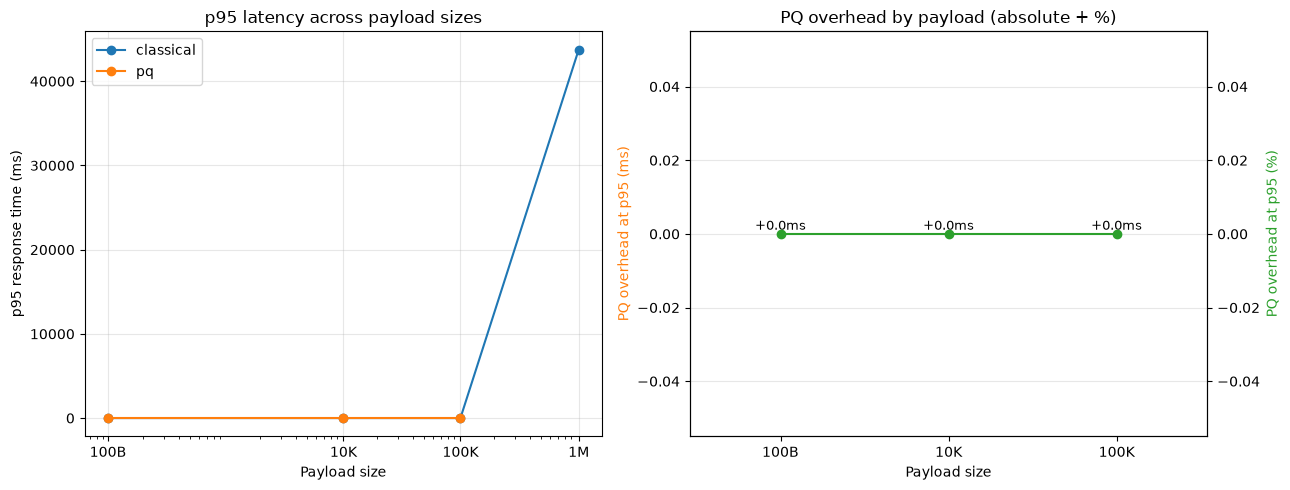


PQ overhead absolute (ms): {'100B': 0.0, '10K': 0.0, '100K': 0.0, '1M': nan}
PQ overhead relative (%):  {'100B': 0.0, '10K': 0.0, '100K': 0.0, '1M': nan}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: absolute p95 by payload for both configs
x_vals = [PAYLOAD_BYTES[p] for p in PAYLOAD_ORDER]
axes[0].plot(x_vals, pivot_p95.loc["classical"], "o-", label="classical", color="#1f77b4")
axes[0].plot(x_vals, pivot_p95.loc["pq"],        "o-", label="pq",        color="#ff7f0e")
axes[0].set_xscale("log")
axes[0].set_xticks(x_vals)
axes[0].set_xticklabels(PAYLOAD_ORDER)
axes[0].set_xlabel("Payload size")
axes[0].set_ylabel("p95 response time (ms)")
axes[0].set_title("p95 latency across payload sizes")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: PQ overhead (ms added) by payload
overhead_abs = pivot_p95.loc["pq"] - pivot_p95.loc["classical"]
overhead_pct = (pivot_p95.loc["pq"] / pivot_p95.loc["classical"] - 1) * 100

ax = axes[1]
bars = ax.bar(PAYLOAD_ORDER, overhead_abs, color="#ff7f0e", alpha=0.7)
ax.set_ylabel("PQ overhead at p95 (ms)", color="#ff7f0e")
ax.set_xlabel("Payload size")
ax.set_title("PQ overhead by payload (absolute + %)")
ax.grid(True, axis="y", alpha=0.3)

ax2 = ax.twinx()
ax2.plot(PAYLOAD_ORDER, overhead_pct, "o-", color="#2ca02c")
ax2.set_ylabel("PQ overhead at p95 (%)", color="#2ca02c")

for bar, v in zip(bars, overhead_abs):
    ax.annotate(f"{v:+.1f}ms", xy=(bar.get_x() + bar.get_width()/2, v),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("03-payload-sweep.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nPQ overhead absolute (ms):", overhead_abs.round(2).to_dict())
print("PQ overhead relative (%): ",  overhead_pct.round(2).to_dict())

## Narrative numbers for the blog post

In [7]:
print("If the hypothesis holds, the PQ-overhead row should be close to flat — the")
print("KEM is paid once per connection, the record layer is identical. If it rises")
print("with payload size, something else is going on (congestion, loadgen saturation).")
print("")
print(f"PQ overhead at 100B:  {overhead_abs['100B']:+.2f} ms ({overhead_pct['100B']:+.1f}%)")
print(f"PQ overhead at 1M:    {overhead_abs['1M']:+.2f} ms ({overhead_pct['1M']:+.1f}%)")
print(f"Delta (1M - 100B):    {overhead_abs['1M'] - overhead_abs['100B']:+.2f} ms")

If the hypothesis holds, the PQ-overhead row should be close to flat — the
KEM is paid once per connection, the record layer is identical. If it rises
with payload size, something else is going on (congestion, loadgen saturation).

PQ overhead at 100B:  +0.00 ms (+0.0%)
PQ overhead at 1M:    +nan ms (+nan%)
Delta (1M - 100B):    +nan ms
